For question 3, the research question i have chosen is question 5, How do choices about data such as i) amount of training data and ii) balance of classes in a
classification problem affect the performance of a neural network?

I will be seperating this notebook into 2 halves, half i testing the amount of training data and half ii testing the balance of the classes. 

To start, we need the same imports used in notebook 2. We'll start off with the system import packages that make it possible to call functions from other files:

In [33]:
#system imports - chatgpt suggestion
import sys
import os
sys.path.append(os.path.abspath(".."))

Next, we need to import the same packages as the previous notebooks. Pandas allows us to store the data in a dataframe, numpy is for mathematical functions, matplotlib and seaborn handle data visualization and display, and the sklearn imports allow us to analyse the accuracy of the neural network we create.

In [34]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

We also need our helper functions. For part i, we can reuse the functions used in question 2, but for part ii we have had to create a new function to imbalance the classes. The function purposes is commmented next to the function.

In [35]:
from functions import load_data #loads the cleaned penguin size dataset from where it is stored
from functions import split_data #splits the data into training and testing sets
from functions import split_train_test #splits features and labels into training and testing sets
from functions import scale_features #scales the training features using standard scaler
from functions import train_neural_network #trains mlp neural network on training data
from functions import evaluate_neural_network #evaluates the performance of the trained neural network
from functions import imbalance_classes #imbalances classes for question 3 ii


First half - part i

To investigate the impacts of amount of training data on the accuracy of the model, we can redo what we did in notebook 2 but change the proportions of the data split when using the function to split the dataset into training and testing. In notebook 2, we used 80% training data and 20% testing data and got an accuracy of 98.5%. In this investigation, we can proportion the dataset differently then train and test the model to compare their accuracies. We will use different proportions and then compare the results.

As we did in question 2, we need to start by importing and preparing the data. We will use the load_data functions as well as the split_data function to have the data split into target and feature ready to be split into testing and training groups.

In [62]:
#importing data with load_data function
df =load_data("../../data/processed/penguins_size_cleaned.csv") #data loaded in
print(df.head()) #print first 5 rows of the dataframe to verify data loaded correctly

#splitting data into target (species) and features (culmen length, depth, flipper length, body mass)
feature_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g',] #feature variables to use
target_col = 'species' #target variabke to predict - species
x, y = split_data(df, feature_cols, "species") #feature and target variables have been assigned to x and y)

  species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen              39.1             18.7              181.0   
1  Adelie  Torgersen              39.5             17.4              186.0   
2  Adelie  Torgersen              40.3             18.0              195.0   
3  Adelie  Torgersen              36.7             19.3              193.0   
4  Adelie  Torgersen              39.3             20.6              190.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3       3450.0  FEMALE  
4       3650.0    MALE  


Next, we encode the target variables into numbers again:

In [63]:
#using the label encoder to give target values numerical values
labels = LabelEncoder() #calling the label encoder from sklearn
y = labels.fit_transform(y) #encoding the species labels into numerical values
print("Encoded species labels:", labels.classes_) #printing the encoded species labels for later
#adelie = 0, chinstrap = 1, gentoo = 2

Encoded species labels: ['Adelie' 'Chinstrap' 'Gentoo']


One important thing to note is that the accuracy percentage is not equal in each case as the proportion of training/test data is varying, so the accuracy score may incorrectly represent how well it performed relative to other versions, so when comparing the differences the number of incorrect predictions shows a more accurate picture.

Now that we have the data split into target and feature groups, we need to split it into training and testing, use it to train the model, then find the accuracy just as we did in notebook 2. In notebook 2, we did 80/20 which gave us 98.5% accuracy, so we can expect to get lower accuracies from smaller training sets. In this notebook, we will test training/test splits of 5/95, 20/80, 40/60, 50/50, 60,40, 80/20 and 95/5 and find the accuracy and confusion matrix for each, then compare the proportions to see how the training set size impacts model accuracy. Starting with 9/95, we will first split the training set:

In [64]:
#splitting the data into training and testing sets in the proportion 5:95 
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.95, random_state = 42)

Now we need to follow the same process from notebook 2. The scaling of the training data so that the model can compare each equally comes next:

In [65]:
#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

The last thing to do before training the neural networks is to create a series of lists to make data comparison easier a bit later on. We will the append the data split, accuracy percentage and number of incorrect predictions to these lists to make plotting a table quick and easy.

In [70]:
#lists for later use
data_split = ["5/95", "20/80", "40/60", "50/50", "60/40", "80/20", "95/5"] #list of data splits
accuracy_score = []
incorrect_predictions = []

We can now create and train the neural network on this data. As the training data is a very small fraction of the whole dataset, we can assume it will not be as accurate. After training it, we can use the evaluation function to see how accurate it really is and plot the confusion matrix to see where it is getting mixed up.

In [71]:
#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)


In [72]:
#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 0.9661538461538461
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       142
           1       0.92      0.91      0.91        65
           2       1.00      1.00      1.00       118

    accuracy                           0.97       325
   macro avg       0.96      0.96      0.96       325
weighted avg       0.97      0.97      0.97       325



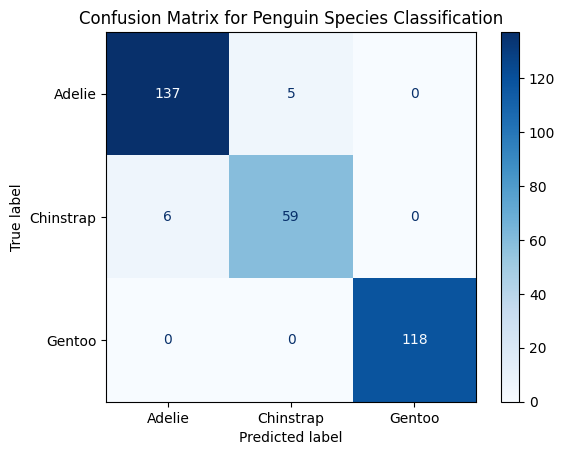

In [73]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_01_0595.png")
plt.show()

Trained on 5% of the data and tested on 95%, the neural network performed quite well. It has an accuracy of 96.6% and performed perfectly predicting the gentoo penguins. In question 2, the model struggled predicting adelie and chinstrap penguins but was only incorrect once, compared to 11 times here. This suggests that the proportion of training data really is important to prediction accuracy, although even at 5/95 the model performed fairly well. We will now repeat this experiment for 20/80, 40/60, 50/50, 60/40 and 80/20.

In [74]:
#training neural network on 20/80 split

#splitting the data into training and testing sets in the proportion 20:80
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.80, random_state = 42)

#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

#appending accuracy score and incorrect predictions to list
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 0.9817518248175182
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       125
           1       0.96      0.94      0.95        51
           2       1.00      1.00      1.00        98

    accuracy                           0.98       274
   macro avg       0.98      0.98      0.98       274
weighted avg       0.98      0.98      0.98       274



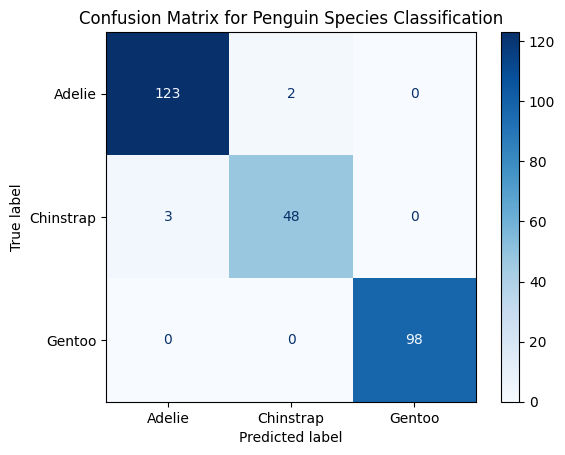

In [75]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_02_2080.png")
plt.show()

When trained on 20% of the data, the model preforms better than the previous perfomance at 5%. Once again, there is no incorrect predictions for gentoo penguins and the numbers of incorrect predictions for adelie and chinstrap penguins has decreases to 5 total. This model version has an accuracy score of 98.17%.

In [76]:
#training neural network on 40/60 split

#splitting the data into training and testing sets in the proportion 40:60
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.60, random_state = 42)

#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

#appending accuracy score and incorrect predictions to list
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 0.9902912621359223
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99        92
           1       0.97      0.97      0.97        37
           2       1.00      1.00      1.00        77

    accuracy                           0.99       206
   macro avg       0.99      0.99      0.99       206
weighted avg       0.99      0.99      0.99       206



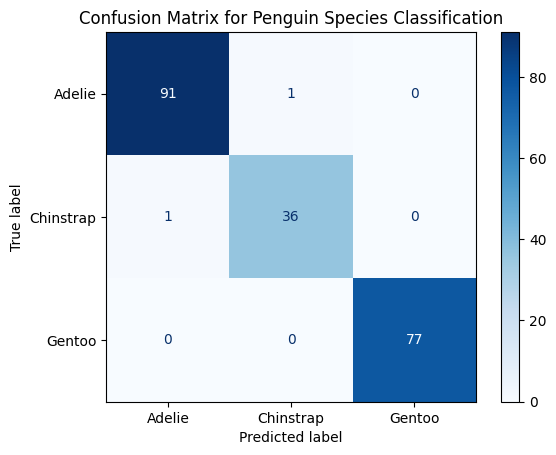

In [77]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_03_4060.png")
plt.show()

This version of the model performed very well, only making 2 incorrect predictions and getting an accuracy score of 99%. It also got confused in the same places the other models did.

In [78]:
#training neural network on 50/50 split

#splitting the data into training and testing sets in the proportion 50:50
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.50, random_state = 42)

#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

#appending accuracy score and incorrect predictions to list
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 0.9883040935672515
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99        79
           1       0.97      0.97      0.97        29
           2       1.00      1.00      1.00        63

    accuracy                           0.99       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.99      0.99      0.99       171



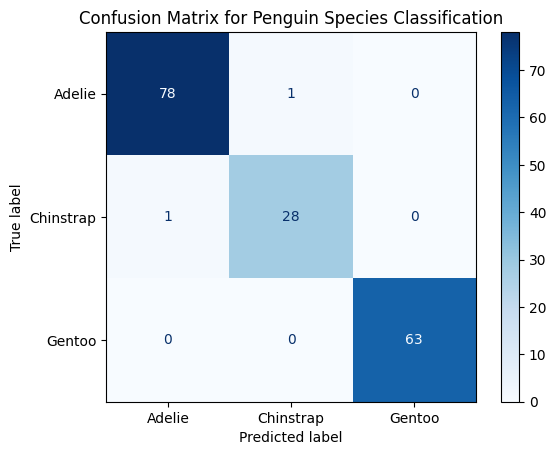

In [79]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_04_5050.png")
plt.show()

This version performed very similarly to the previous version (40/60), with the same 2 incorrect predictions to get an accuracy score of 98.8%. The proportion of test data is smaller here so the accuracy has dropped due to the same number of incorrect predictions taking up a little bit more space.

In [80]:
#training neural network on 60/40 split

#splitting the data into training and testing sets in the proportion 60:40
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.40, random_state = 42)

#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

#appending accuracy score and incorrect predictions to list
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 0.9927007299270073
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        64
           1       0.96      1.00      0.98        24
           2       1.00      1.00      1.00        49

    accuracy                           0.99       137
   macro avg       0.99      0.99      0.99       137
weighted avg       0.99      0.99      0.99       137



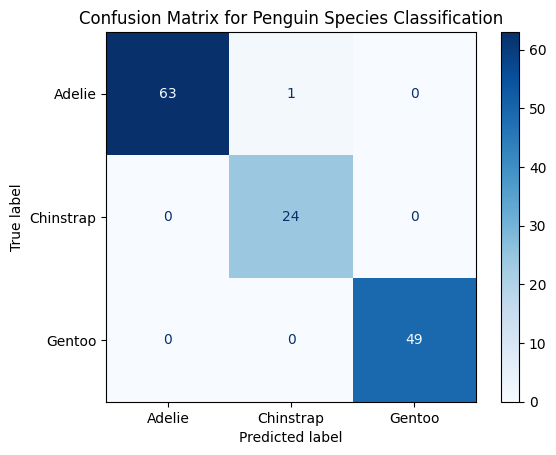

In [81]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_05_6040.png")
plt.show()

This version of the model only made one incorrect prediction and is getting better at differentiating between adelie penguins and chinstrap penguins. the accuracy for this version is 99.3%.

In [82]:
#training neural network on 80/20 split

#splitting the data into training and testing sets in the proportion 80:20
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.20, random_state = 42)

#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

#appending accuracy score and incorrect predictions to list
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 0.9855072463768116
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        35
           1       0.92      1.00      0.96        12
           2       1.00      1.00      1.00        22

    accuracy                           0.99        69
   macro avg       0.97      0.99      0.98        69
weighted avg       0.99      0.99      0.99        69



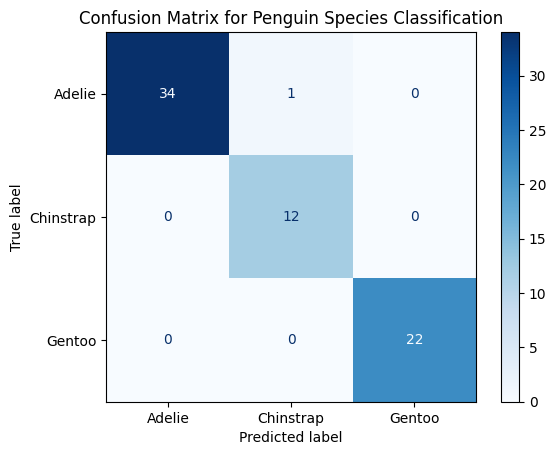

In [83]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_06_8020.png")
plt.show()

This version of the model performs the same as the previous version, with only one incorrect prediction to give an accuracy score of 98.6%

In [84]:
#training neural network on 95/5 split

#splitting the data into training and testing sets in the proportion 95:5
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.05, random_state = 42)

#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

#appending accuracy score and incorrect predictions to list
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         6

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



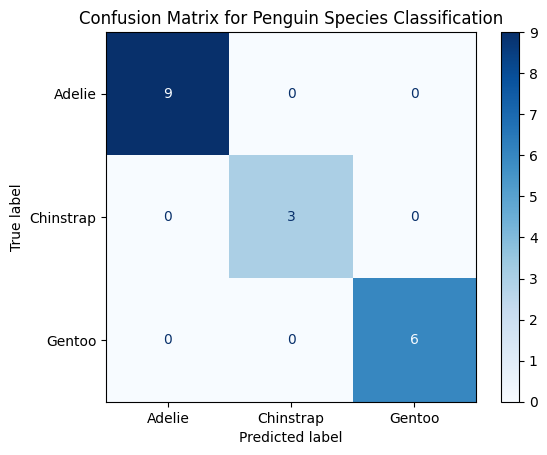

In [85]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_07_9505.png")
plt.show()

With this proportion of the data, the model is 100% accurate and makes no incorrect predictions.

Now that we have all the data from the different versions of the model, we can draw some conclusions on how the model works trained on different amounts of data. The MLP neural network naturally has very good performance, even when trained on a small proportion of the dataset. We can now use pandas to create a table showing the data split, percentage accuracy for each model and the number of incorrect predictions.

In [89]:
#using pandas to create a dataframe of our findings for easy comparisons
results_df = pd.DataFrame({"Data Split": data_split, "Incorrect Predictions": incorrect_predictions, "Accuracy": accuracy_score, })
results_df #displaying dataframe

,Data Split,Incorrect Predictions,Accuracy
0,5/95,11,0.966154
1,20/80,5,0.981752
2,40/60,2,0.990291
3,50/50,2,0.988304
4,60/40,1,0.992701
5,80/20,1,0.985507
6,95/5,0,1.000000


Looking at the table above, we can see that the accuracy trends upwards with a couple exceptions at 50/50 and 80/20, which are a little lower than the ones before them. Both the 50/50 and 80/20 model versions perform the same as the model before them in terms of incorrect predictions, but due to their smaller testing sets, the incorrect predictions seem larger and cause a larger accuracy decrease. Looking at the incorrect predictions columns, we can see that the more data the model is trained on, the more accurate the model becomes. For example, when trained on 5% of the data and tested on 95%, 11 incorrect predictions were made, however when trained on 95% of the data and tested on 5%, 0 incorrect predictions were made. The largest jump was between 5% training data to 20% training data, where 6 incorrect predictions were fixed.

The dataset I chose for this investigation was quite small, so the proportions of data were all fairly small. If the dataset chosen was larger, the 5% set of training data would have been larger and the model would have had more data samples to train on, so would likely have been more accurate. I expected the dataset to be less accurate at 5% and 20%, but the mlp neural network chosen for this is very well suited to the data so has very good accuracy even when trained at low training data percentages.